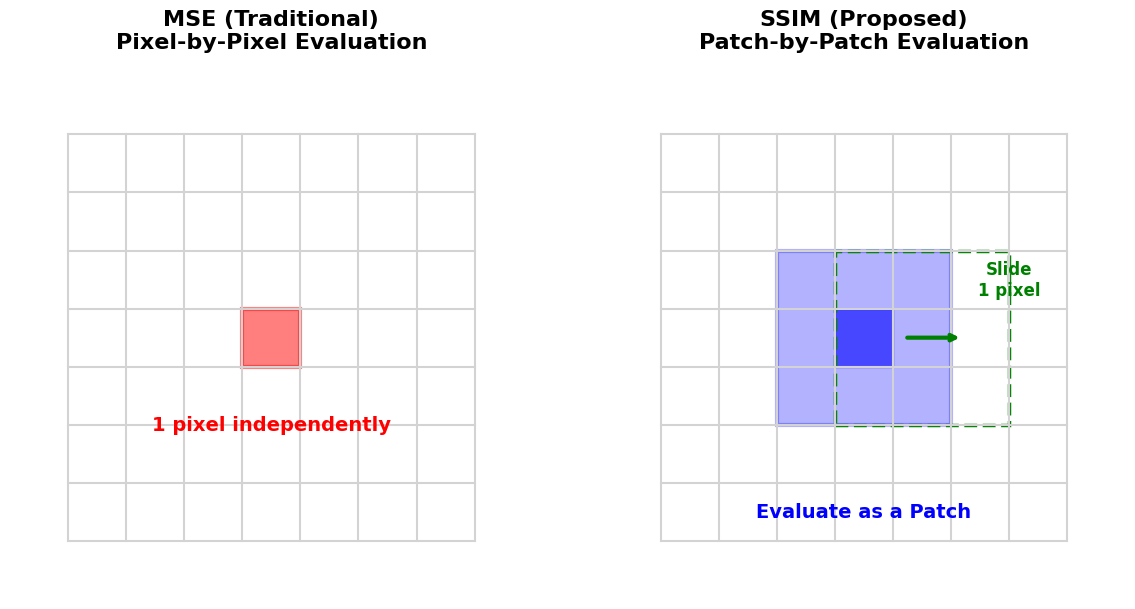

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_grid(ax, grid_size, offset_x=0, offset_y=0):
    """グリッドを描画する補助関数"""
    for i in range(grid_size + 1):
        # 横線
        ax.plot([offset_x, offset_x + grid_size], [offset_y + i, offset_y + i], color='lightgray', lw=1.5)
        # 縦線
        ax.plot([offset_x + i, offset_x + i], [offset_y, offset_y + grid_size], color='lightgray', lw=1.5)

# 描画設定
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
grid_size = 7 # 全体のグリッドサイズ（視認性のため7x7で表現）

# ==========================================
# 左の図：MSE（ピクセル単体の評価）
# ==========================================
ax1.set_xlim(-1, grid_size + 1)
ax1.set_ylim(-1, grid_size + 1)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title("MSE (Traditional)\nPixel-by-Pixel Evaluation", fontsize=16, fontweight='bold', pad=20)

draw_grid(ax1, grid_size)

# 対象の1ピクセルを赤くハイライト
target_x, target_y = 3, 3
rect_mse = patches.Rectangle((target_x, target_y), 1, 1, linewidth=3, edgecolor='red', facecolor='red', alpha=0.5)
ax1.add_patch(rect_mse)

# 説明テキスト
ax1.text(target_x + 0.5, target_y - 1.0, "1 pixel independently", 
         color='red', fontsize=14, ha='center', va='center', fontweight='bold')

# ==========================================
# 右の図：SSIM（パッチ単位の評価）
# ==========================================
ax2.set_xlim(-1, grid_size + 1)
ax2.set_ylim(-1, grid_size + 1)
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title("SSIM (Proposed)\nPatch-by-Patch Evaluation", fontsize=16, fontweight='bold', pad=20)

draw_grid(ax2, grid_size)

# パッチの中心ピクセル
center_x, center_y = 3, 3
patch_radius = 1 # 3x3のパッチを表現（実際の11x11のデフォルメ）

# 対象のパッチを青くハイライト
rect_ssim = patches.Rectangle((center_x - patch_radius, center_y - patch_radius), 
                              patch_radius*2 + 1, patch_radius*2 + 1, 
                              linewidth=3, edgecolor='blue', facecolor='blue', alpha=0.3)
ax2.add_patch(rect_ssim)

# 中心ピクセルを少し濃くする
center_pixel = patches.Rectangle((center_x, center_y), 1, 1, linewidth=1, edgecolor='blue', facecolor='blue', alpha=0.6)
ax2.add_patch(center_pixel)

# スライド（移動）を表現する点線のパッチ（右に1ピクセルずれた状態）
rect_slide = patches.Rectangle((center_x - patch_radius + 1, center_y - patch_radius), 
                               patch_radius*2 + 1, patch_radius*2 + 1, 
                               linewidth=2.5, edgecolor='green', facecolor='none', linestyle='--')
ax2.add_patch(rect_slide)

# スライドを示す矢印
ax2.annotate("", xy=(center_x + patch_radius + 1.2, center_y + 0.5), 
             xytext=(center_x + patch_radius + 0.2, center_y + 0.5),
             arrowprops=dict(arrowstyle="->", color="green", lw=3))

# 説明テキスト
ax2.text(center_x + 0.5, center_y - 2.5, "Evaluate as a Patch", 
         color='blue', fontsize=14, ha='center', va='center', fontweight='bold')
ax2.text(center_x + 3.0, center_y + 1.5, "Slide\n1 pixel", 
         color='green', fontsize=12, ha='center', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

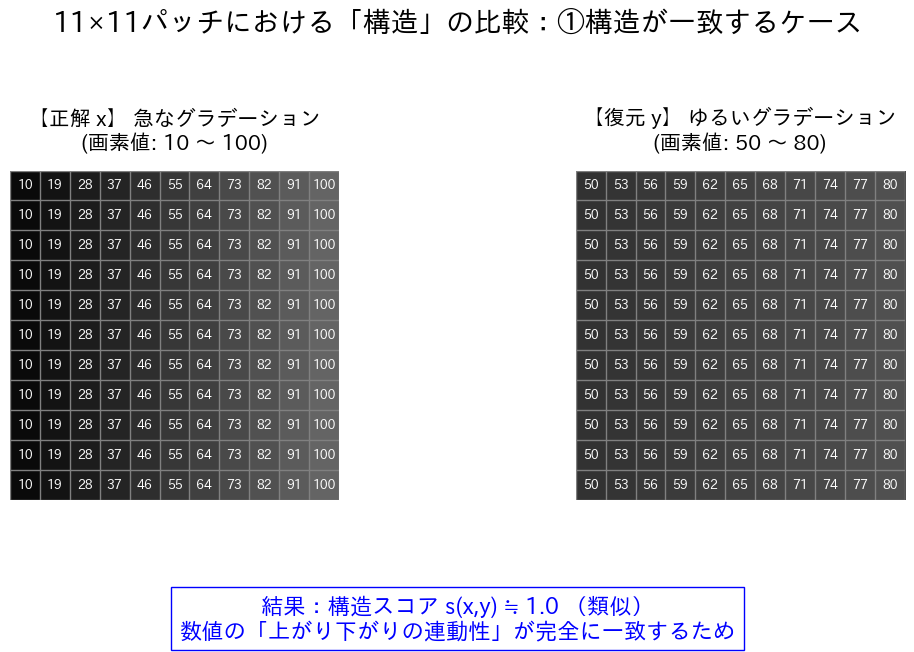

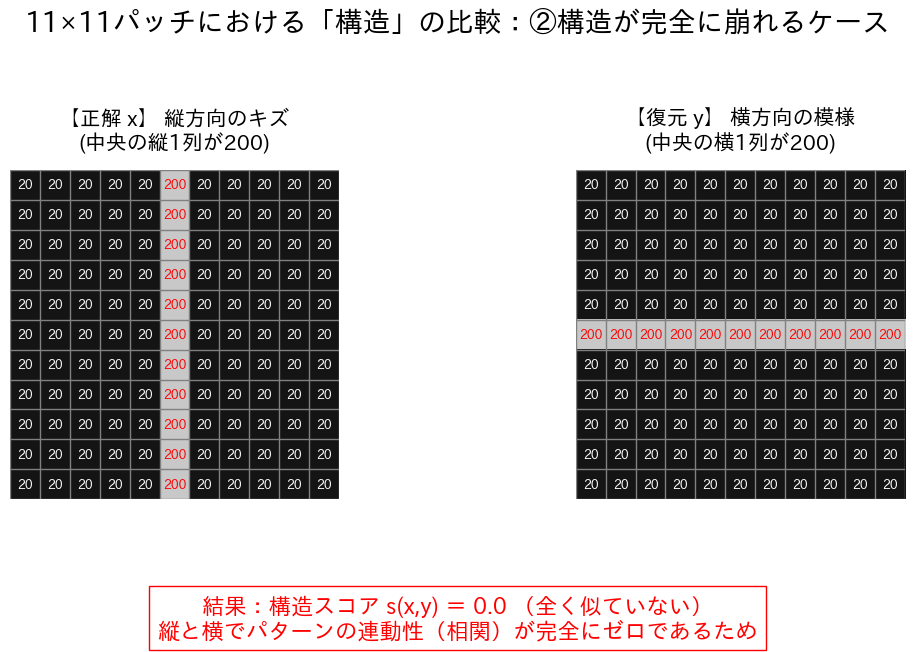

In [12]:
# !pip install japanize-matplotlib

import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

# ==========================================
# 11x11パッチのデータ作成 (画素値: 0〜255)
# ==========================================
Z_grad_x = np.linspace(10, 100, 11).reshape(1, 11).repeat(11, axis=0)
Z_grad_y = np.linspace(50, 80, 11).reshape(1, 11).repeat(11, axis=0)

Z_scratch_x = np.full((11, 11), 20.0)
Z_scratch_x[:, 5] = 200.0

Z_scratch_y = np.full((11, 11), 20.0)
Z_scratch_y[5, :] = 200.0

# ==========================================
# 共通の描画関数
# ==========================================
def plot_pixel_grid(ax, data, title):
    im = ax.imshow(data, cmap='gray', vmin=0, vmax=255)
    # タイトルの位置を少し上に離す(pad=15)
    ax.set_title(title, fontsize=15, fontweight='bold', pad=15)
    ax.axis('off')
    
    for i in range(12):
        ax.axhline(i - 0.5, color='gray', linewidth=1)
        ax.axvline(i - 0.5, color='gray', linewidth=1)
        
    for i in range(11):
        for j in range(11):
            val = int(data[i, j])
            text_color = 'white' if val < 128 else 'black'
            if val == 200:
                text_color = 'red'
                
            ax.text(j, i, str(val), ha='center', va='center', 
                    color=text_color, fontsize=9, fontweight='bold')

# ==========================================
# 【画像1枚目】 上段：ケース1（構造一致）
# ==========================================
# 高さを6から7に変更し、縦方向のスペースを確保
fig1, axes1 = plt.subplots(1, 2, figsize=(12, 7)) 
fig1.suptitle("11×11パッチにおける「構造」の比較：①構造が一致するケース", fontsize=20, fontweight='bold', y=0.95)

plot_pixel_grid(axes1[0], Z_grad_x, "【正解 x】 急なグラデーション\n(画素値: 10 〜 100)")
plot_pixel_grid(axes1[1], Z_grad_y, "【復元 y】 ゆるいグラデーション\n(画素値: 50 〜 80)")

fig1.text(0.5, 0.08, 
         "結果：構造スコア s(x,y) ≒ 1.0 （類似）\n"
         "数値の「上がり下がりの連動性」が完全に一致するため", 
         ha='center', va='center', fontsize=16, color='blue', fontweight='bold', 
         bbox=dict(facecolor='white', alpha=1.0, edgecolor='blue', pad=6))

# top=0.72 にして、グラフの上部に十分な余白を作る
fig1.subplots_adjust(left=0.05, right=0.95, top=0.72, bottom=0.25, wspace=0.1)

# ==========================================
# 【画像2枚目】 下段：ケース2（構造がゼロ：無相関）
# ==========================================
# 同様に高さを7に変更
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 7))
fig2.suptitle("11×11パッチにおける「構造」の比較：②構造が完全に崩れるケース", fontsize=20, fontweight='bold', y=0.95)

plot_pixel_grid(axes2[0], Z_scratch_x, "【正解 x】 縦方向のキズ\n(中央の縦1列が200)")
plot_pixel_grid(axes2[1], Z_scratch_y, "【復元 y】 横方向の模様\n(中央の横1列が200)")

fig2.text(0.5, 0.08, 
         "結果：構造スコア s(x,y) ＝ 0.0 （全く似ていない）\n"
         "縦と横でパターンの連動性（相関）が完全にゼロであるため", 
         ha='center', va='center', fontsize=16, color='red', fontweight='bold', 
         bbox=dict(facecolor='white', alpha=1.0, edgecolor='red', pad=6))

# 同様にtop=0.72に変更
fig2.subplots_adjust(left=0.05, right=0.95, top=0.72, bottom=0.25, wspace=0.1)

plt.show()